In [18]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv('suzuki_stock_data.csv')

In [3]:
df.index = pd.to_datetime(df['Date'])

In [4]:
df["returns"] = df["Close"].pct_change()
df["lag1"] = df["returns"].shift(1)
df["lag2"] = df["returns"].shift(2)
df["rolling_mean3"] = df["returns"].rolling(3).mean()
df["rolling_std3"] = df["returns"].rolling(3).std()

In [5]:
df.dropna(subset = ['lag1', 'lag2', 'rolling_mean3'], inplace = True)

In [6]:
df.isnull().sum()

Date             0
Close            0
High             0
Low              0
Open             0
Volume           0
returns          0
lag1             0
lag2             0
rolling_mean3    0
rolling_std3     0
dtype: int64

In [10]:
X = df[['lag1', 'lag2', 'rolling_mean3', 'rolling_std3']]
df['directions'] = np.where(df['returns'] > 0, 1, 0)
y = df['directions']

In [20]:
# Splitting the data into training and testing sets
split = int(0.9 * len(df))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [21]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93       135
           1       0.91      0.97      0.94       143

    accuracy                           0.94       278
   macro avg       0.94      0.93      0.94       278
weighted avg       0.94      0.94      0.94       278



In [22]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[122,  13],
       [  5, 138]])

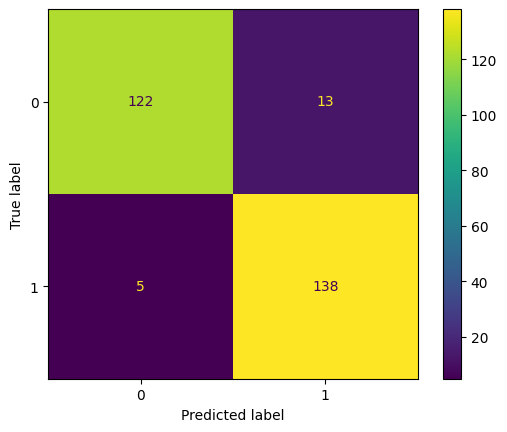

In [23]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfc.classes_)
disp.plot()